In [11]:
#Data preparation
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler 
#from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier


from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=DeprecationWarning)
simplefilter(action='ignore', category=FutureWarning)

## Uncomment the following part in order to execute in the Google cloud
# import google.datalab.storage as storage
# from io import BytesIO

# mybucket = storage.Bucket("applied-syntax-257623-1") 
# data_csv = mybucket.object("AB_NYC_2019.csv")

# uri = data_csv.uri 
# %gcs read --object $uri --variable data_csv
# #Loading the dataset 
# dataset = pd.read_csv(BytesIO(data_csv))
## end of cloud code 

#load data
#dataset = pd.read_csv('AB_NYC_2019_sample_complete.csv')
dataset = pd.read_csv('AB_NYC_2019.csv')

dataset.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


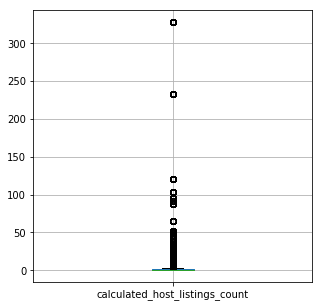

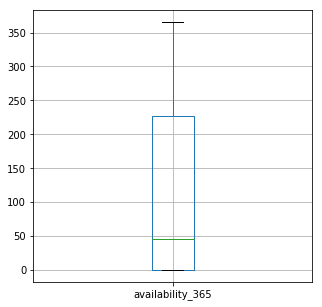

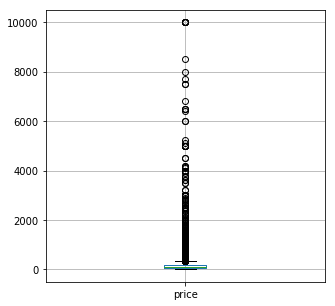

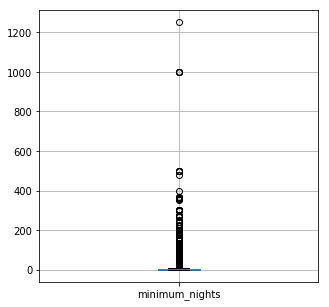

                           id       host_id   latitude  longitude       price  \
room_type                                                                       
Entire home/apt  1.843818e+07  6.175593e+07  40.728649 -73.960696  211.794246   
Private room     1.946893e+07  7.247514e+07  40.729208 -73.942924   89.780973   
Shared room      2.300378e+07  1.026241e+08  40.730514 -73.943343   70.127586   

                 minimum_nights  number_of_reviews  reviews_per_month  \
room_type                                                               
Entire home/apt        8.506907          22.842418           1.306578   
Private room           5.377900          24.112962           1.445209   
Shared room            6.475000          16.600000           1.471726   

                 calculated_host_listings_count  availability_365  
room_type                                                          
Entire home/apt                       10.698335        111.920304  
Private room            

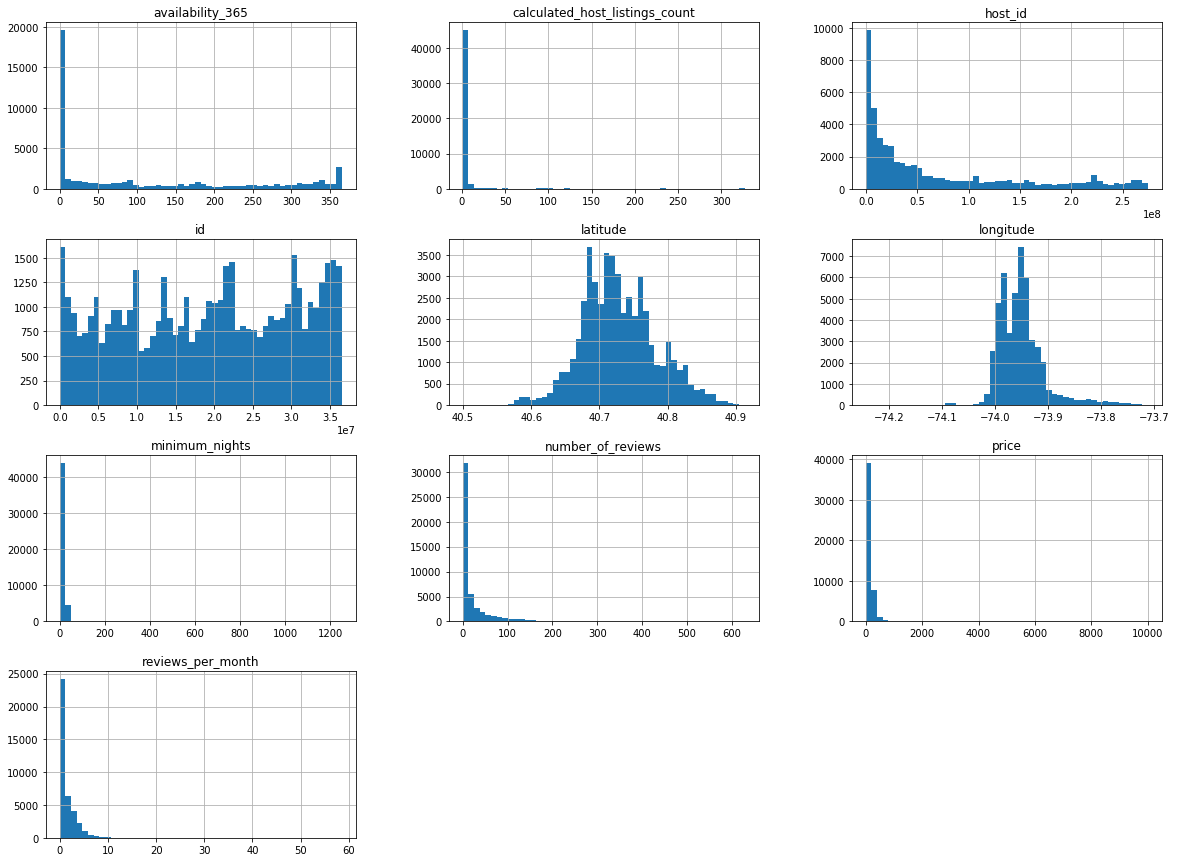

In [12]:
###
### Understanding the data
###

# describes summary stats for all features in full data set
dataset.describe(include='all')

dataset.boxplot(column=['calculated_host_listings_count'],figsize=(5,5))
plt.show()
dataset.boxplot(column=['availability_365'], figsize=(5,5))
plt.show()
dataset.boxplot(column=['price'], figsize=(5,5))
plt.show()
dataset.boxplot(column=['minimum_nights'], figsize=(5,5))
plt.show()

group_by_room_type = dataset.groupby(by=['room_type'])
room_type_avg = group_by_room_type.mean()
print(room_type_avg)

group_by_neighbourhood_group = dataset.groupby(by=['neighbourhood_group'])
neighbourhood_group_avg = group_by_neighbourhood_group.mean()
print(neighbourhood_group_avg)

group_by_neighbourhood = dataset.groupby(by=['neighbourhood'])
neighbourhood_avg = group_by_neighbourhood.mean()
print(neighbourhood_avg)

# Generate histograms for each numeric variable
dataset.hist(bins=50, figsize=(20,15))
plt.show()

In [13]:
###
### Trimming the Data
###

# Drop all row that contains missing values on the review columns
# decision to drop because it may indicate they registered their house
# at Airbnb but ended up not renting it yet (20% of all listing: 10k of 48k) 
print("1:", dataset.shape)
dataset = dataset.dropna(axis=0)

# Drop hosts with more than 1 listing
dataset = dataset[dataset['calculated_host_listings_count'] < 2]

# should be 6 or less
dataset = dataset[dataset['minimum_nights'] <= 6]

# Drop anything more than $159 
dataset = dataset[dataset['price'] <= 159]

#remove identifying columns and calculated one
dataset = dataset.drop([ 'id', 'name', 'host_id', 'host_name','latitude', 'longitude', 'last_review', 'calculated_host_listings_count'], axis=1)
print("6:", dataset.shape)


dataset.head()

1: (48895, 16)
6: (15132, 8)


,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,194
7,Manhattan,Hell's Kitchen,Private room,79,2,430,3.47,220
8,Manhattan,Upper West Side,Private room,79,2,118,0.99,0
10,Manhattan,Upper West Side,Entire home/apt,135,5,53,0.43,6
11,Manhattan,Hell's Kitchen,Private room,85,2,188,1.50,39


In [14]:
### 
### Dealing with categorical variables
### 

# Preparing the data dealing with categorical variables and numeric
categorical_columns = ['room_type', 'neighbourhood_group', 'neighbourhood']
numeric_columns = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']

label_encoders = {}
dataset_processed= dataset.filter(numeric_columns, axis=1)

all_col_names_no_dummies = []
all_col_names_no_dummies_2 = []

col_dummy_deleted = []
col_dummy_deleted_2 = []
all_col_names=[]

# For each categorical column: fit a label encoder, transform and add it to our new dataframe.
# Variable 'all_col_names' to store column names in the order of the dataset
for col in sorted(categorical_columns):
    new_le = LabelEncoder()
    dataset_processed[col] = new_le.fit_transform(dataset[col])
    label_encoders[col] = new_le
    
    #Saving column names for each new dataset
    col_names_tmp = sorted(dataset[col].unique())
    if(col is 'neighbourhood'):
        all_col_names.extend(col_names_tmp[0:])
        col_dummy_deleted.append(col_names_tmp[0])
        all_col_names_no_dummies.extend(col_names_tmp[1:])
    elif(col is 'neighbourhood_group'):
        all_col_names.extend(col_names_tmp[0:])
        col_dummy_deleted.append(col_names_tmp[0])
        all_col_names_no_dummies.extend(col_names_tmp[1:])
        all_col_names_no_dummies_2.extend(col_names_tmp[1:])
    else:
        all_col_names_no_dummies_2.extend(col_names_tmp[1:])
        all_col_names.extend(col_names_tmp[0:])
        col_dummy_deleted.append(col_names_tmp[0])
        all_col_names_no_dummies.extend(col_names_tmp[1:])


all_col_names.extend(numeric_columns.copy())
all_col_names_no_dummies_2.extend(numeric_columns.copy())
col_dummy_deleted_2 = list(set(all_col_names) - set(all_col_names_no_dummies_2))

# For processing the OneHotEncoder: get columns indexes, fit and transform
categorical_columns_idx = [dataset_processed.columns.get_loc(col) 
                   for col in categorical_columns]
ohe = OneHotEncoder(categorical_features=categorical_columns_idx, 
                    sparse=False, handle_unknown="ignore")
dataset_processed_array = ohe.fit_transform(dataset_processed)

ds_all_processed = pd.DataFrame(dataset_processed_array)
ds_all_processed.columns = all_col_names

# Create new dataset removing the extra dummies
dataset_ready = ds_all_processed.copy()
dataset_ready_smaller = ds_all_processed.copy()

dataset_ready = dataset_ready.drop(col_dummy_deleted, axis=1)
dataset_ready_smaller = dataset_ready_smaller.drop(col_dummy_deleted_2, axis=1)

print ("\n\nDataset ready complete:\n", dataset_ready.head(), "\nShape: ", dataset_ready.shape)
print ("\n\n Dataset without the 'neighborhood':\n", dataset_ready_smaller.head(), "\nShape: ", dataset_ready_smaller.shape)



Dataset ready complete:
    Arden Heights  Arrochar  Arverne  Astoria  Bath Beach  Battery Park City  \
0            0.0       0.0      0.0      0.0         0.0                0.0   
1            0.0       0.0      0.0      0.0         0.0                0.0   
2            0.0       0.0      0.0      0.0         0.0                0.0   
3            0.0       0.0      0.0      0.0         0.0                0.0   
4            0.0       0.0      0.0      0.0         0.0                0.0   

   Bay Ridge  Bay Terrace  Bay Terrace, Staten Island  Baychester  ...  \
0        0.0          0.0                         0.0         0.0  ...   
1        0.0          0.0                         0.0         0.0  ...   
2        0.0          0.0                         0.0         0.0  ...   
3        0.0          0.0                         0.0         0.0  ...   
4        0.0          0.0                         0.0         0.0  ...   

   Brooklyn  Manhattan  Queens  Staten Island  Privat

price                  1.000000
minimum_nights         0.107429
number_of_reviews      0.086828
neighbourhood          0.075432
neighbourhood_group    0.044977
availability_365       0.040446
reviews_per_month      0.031574
room_type             -0.584075
Name: price, dtype: float64
price_room             1.000000
price                  0.749271
neighbourhood          0.111078
availability_365       0.088470
neighbourhood_group    0.078504
number_of_reviews      0.069863
room_type              0.051231
reviews_per_month      0.001393
minimum_nights        -0.010503
weight_type_room      -0.051231
Name: price_room, dtype: float64


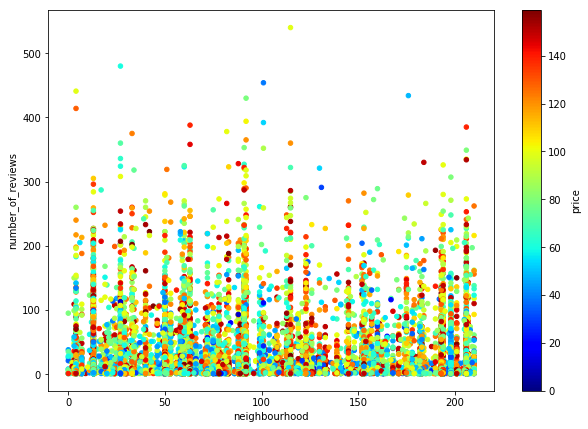

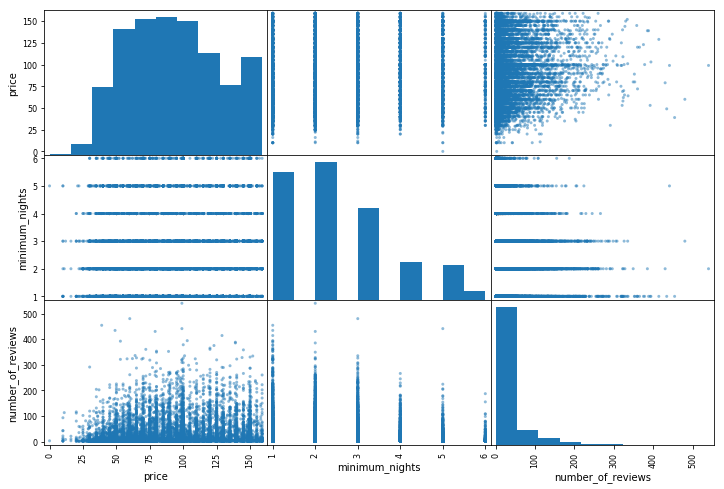

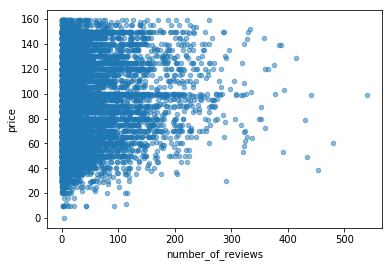

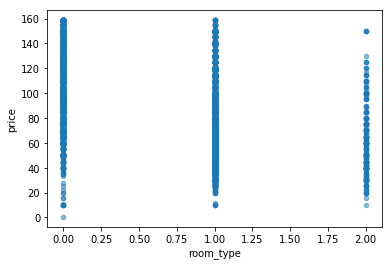

In [15]:
###
### Overall Data analyses using the dataset_processed 
### (numerical variables and categorical variables after label enconder, so all numeric columns)

dataset_processed['price'] = dataset['price']
dataset_processed.plot(kind="scatter", x="neighbourhood", y="number_of_reviews",figsize=(10,7), 
                       c='price', cmap=plt.get_cmap("jet"), colorbar=True, sharex=False)

# Shows the correlation between each independent variable correlates with this dependent variable
corr_matrix = dataset_processed.corr()
print(corr_matrix["price"].sort_values(ascending=False))


from pandas.plotting import scatter_matrix
attributes = ["price", "minimum_nights", "number_of_reviews"]
scatter_matrix(dataset_processed[attributes], figsize=(12, 8))

dataset_processed.plot(kind="scatter", x="number_of_reviews", y="price", alpha=0.5)
dataset_processed.plot(kind="scatter", x="room_type", y="price", alpha=0.5)

# Because each house has different square footage and each neighborhood has different home prices, what we really need is the price per sqft. So, we add a new variable “price_per_sqft”. We then check to see how much this new independent variable correlates with the last sold price.
dataset_processed['weight_type_room']= dataset_processed['room_type'].apply(lambda x: 3 if x==0 else (2 if x==1 else 1))

dataset_processed['price_room'] = dataset_processed['price']/dataset_processed['weight_type_room']
corr_matrix = dataset_processed.corr()
print(corr_matrix["price_room"].sort_values(ascending=False))

In [18]:
# X_1 stores all the attributes
# X_2 stores all the attributes except the 'neighbourhood' 
# X_2 stores all the attributes except the 'neighbourhood' and 'neighbourhood_group' 
# y is the 'price' column 

X_1 = dataset_ready.iloc[:,:].values
X_2 = dataset_ready_smaller.iloc[:,:].values

price = dataset.columns.get_loc("price")
y = dataset.iloc[:, price].values

print("X_1:", X_1[0,:], "\n\n", "X_2", X_2[0,:], "\n\n", "y:",y[0])

# Split the data in trainning and testing sets
X_train_1, X_test_1, y_train, y_test = train_test_split(X_1, y, test_size = 0.3, random_state=0)
X_train_2, X_test_2, y_train, y_test = train_test_split(X_2, y, test_size = 0.3, random_state=0)


X_1: [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     1.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.   

In [19]:
###
### Function used to: create a pipeline with different dimension reduction techniques
###                   using k-fold to better train the training data and predict using the test data
### Parameters:
###    modelObj: regression model
###    X_train: training data
###    X_test: testing data
###    y_train: training class label
###    y_test: testing class label
### Returns:
###   array_accuracy: pipeline.score(X_test, y_test)

def function_regression(nameClassifier, modelObj, X_train, X_test, y_train, y_test):
    
    # Normalize the features
    sc_X = StandardScaler() 
    kf= KFold(n_splits=10, random_state=1, shuffle=True)
    array_accuracy=[]

    for i in ['All','PCA', 'KPCA']:
        print("== ", i)
        if (i=='PCA'):
            redObj = PCA()     
            param_grid = [{'reduce_dim__n_components': [2, 3, 4, 5]}]
        elif (i=='KPCA'):
            redObj = KernelPCA(n_components=5, kernel='rbf')
            param_grid = [{'reduce_dim__n_components': [2, 4, 5], 
                           'reduce_dim__kernel':["rbf", "linear", "poly"]}]
        else:
            redObj = PCA(n_components=None)
            
        objPipeline =  Pipeline([
                                ('normalization', sc_X),
                                ('reduce_dim', redObj),
                                ('classifier', modelObj)
                                ])
        if (i=='PCA' or i=='KPCA'):
            # Grid search to find the best number of attributes to keep
            grid = GridSearchCV(objPipeline, n_jobs=1, param_grid=param_grid)
            grid.fit(X_train, y_train)
            print("Parameters chosen:", grid.best_params_)
            # Set the pipeline with the best parameters
            if (i=='PCA'):
                objPipeline.set_params(reduce_dim__n_components=grid.best_params_.get('reduce_dim__n_components'))
            else:
                objPipeline.set_params(reduce_dim__n_components=grid.best_params_.get('reduce_dim__n_components'), 
                                       reduce_dim__kernel=grid.best_params_.get('reduce_dim__kernel'))
            
        # Train using k-fold cross validation 
        modelAccuracies = cross_val_score(objPipeline, X_train, y_train, cv=kf) 
    
        # Train the whole train data
        objPipeline.fit(X_train, y_train)
        y_pred = objPipeline.predict(X_test)
        classifier = objPipeline.named_steps['classifier']
        if(i=='All' and ((nameClassifier=='LinearRegression2') or (nameClassifier=='LinearRegression1'))):
            coef = classifier.coef_
            if(nameClassifier =='LinearRegression1'):
                col_labels = dataset_ready.columns
            else:
                col_labels = dataset_ready_smaller.columns
            for index in range(0,len(col_labels)-1):
                print('{}: {:.2f}'.format(col_labels[index], (coef[index])))       
        score = objPipeline.score(X_test, y_test)
        print('Test Accuracy: %.3f' %score)
        array_accuracy.append(score)
    return array_accuracy

In [20]:
###
### Multiple Linear Regression
###

mlrObj = LinearRegression()
print("### Multiple Linear Regression:")
print("\n## X_1 (complete features)")
mlr_scores_1 = function_regression('LinearRegression1', mlrObj, X_train_1, X_test_1, y_train, y_test)
print("")
print("\n## X_2 (reduced features)")
mlr_scores_2 = function_regression('LinearRegression2', mlrObj, X_train_2, X_test_2, y_train, y_test)


### Multiple Linear Regression:

## X_1 (complete features)
==  All
Arden Heights: 2.75
Arrochar: -2.28
Arverne: 2.02
Astoria: -1.73
Bath Beach: 11.83
Battery Park City: -8.68
Bay Ridge: -2.72
Bay Terrace: -3.61
Bay Terrace, Staten Island: -0.21
Baychester: -2.23
Bayside: -1.47
Bayswater: -1.29
Bedford-Stuyvesant: 0.31
Belle Harbor: -0.42
Bellerose: 0.35
Belmont: 0.20
Bensonhurst: -0.13
Bergen Beach: 4.09
Boerum Hill: 0.73
Borough Park: -0.40
Briarwood: -0.25
Brighton Beach: 1.86
Bronxdale: -1.23
Brooklyn Heights: -1.17
Brownsville: -0.44
Bull's Head: 1.01
Bushwick: 0.32
Cambria Heights: -0.92
Canarsie: 0.40
Carroll Gardens: 0.55
Castle Hill: -0.82
Castleton Corners: 0.57
Chelsea: -0.49
Chinatown: -1.49
City Island: -0.08
Civic Center: 0.09
Claremont Village: -0.70
Clason Point: 1.36
Clifton: -0.83
Clinton Hill: 2.23
Co-op City: 1.29
Cobble Hill: 0.19
College Point: -0.92
Columbia St: 0.80
Concord: 0.58
Concourse: 0.09
Concourse Village: 0.39
Coney Island: 0.73
Corona: -0.08
Crown Heig

MemoryError: 

In [40]:
###
### Decision Tree
###

from sklearn.tree import DecisionTreeRegressor 
dtrObj = DecisionTreeRegressor()
print("\n### Decision Tree Regression:")
print("\n## X_1 (complete features)")
dtr_scores_1 = function_regression('DecisionTree', dtrObj, X_train_1, X_test_1, y_train, y_test)
print("\n## X_2 (reduced features)")
dtr_scores_2 = function_regression('DecisionTree', dtrObj, X_train_2, X_test_2, y_train, y_test)



### Decision Tree Regression:

## X_1 (complete features)
==  All
Test Accuracy: -0.012
==  PCA
Parameters chosen: {'reduce_dim__n_components': 5}
Test Accuracy: -0.283
==  KPCA
Parameters chosen: {'reduce_dim__n_components': 5, 'reduce_dim__kernel': 'rbf'}
Test Accuracy: -0.075

## X_2 (reduced features)
==  All
Test Accuracy: -0.055
==  PCA
Parameters chosen: {'reduce_dim__n_components': 5}
Test Accuracy: -0.108
==  KPCA
Parameters chosen: {'reduce_dim__n_components': 5, 'reduce_dim__kernel': 'linear'}
Test Accuracy: -0.098


In [41]:
###
### Random Forest
###

from sklearn.ensemble import RandomForestRegressor
rfrObj=RandomForestRegressor()
grid_param = {  
'n_estimators': [10, 15, 20, 25]
}
# Using grid to search for the best number of trees
gd_sr = GridSearchCV(estimator=rfrObj, param_grid=grid_param, cv=5, n_jobs=-1)

gd_sr.fit(X_train_1, y_train)
best_param = gd_sr.best_params_.get("n_estimators")
print("\n## X_1 (complete features)")
print("\n# Random Tree Regression (number of trees: ", best_param, ")")
rfrObj=RandomForestRegressor(n_estimators=best_param)
rfr_scores_1 = function_regression('RandomForest',rfrObj, X_train_1, X_test_1, y_train, y_test)

gd_sr.fit(X_train_2, y_train)
best_param = gd_sr.best_params_.get("n_estimators")
rfrObj=RandomForestRegressor(n_estimators=best_param)
print("\n## X_2 (reduced features)")
print("\n# Random Tree Regression (number of trees: ", best_param, ")")
rfr_scores_2 = function_regression( 'RandomForest', rfrObj, X_train_2, X_test_2, y_train, y_test)


## X_1 (complete features)

# Random Tree Regression (number of trees:  25 )
==  All
Test Accuracy: 0.420
==  PCA
Parameters chosen: {'reduce_dim__n_components': 5}
Test Accuracy: 0.354
==  KPCA
Parameters chosen: {'reduce_dim__n_components': 5, 'reduce_dim__kernel': 'linear'}
Test Accuracy: 0.348

## X_2 (reduced features)

# Random Tree Regression (number of trees:  25 )
==  All
Test Accuracy: 0.324
==  PCA
Parameters chosen: {'reduce_dim__n_components': 5}
Test Accuracy: 0.314
==  KPCA
Parameters chosen: {'reduce_dim__n_components': 5, 'reduce_dim__kernel': 'linear'}
Test Accuracy: 0.313
